# Customer Segmentation using K-Means Clustering

## Objective
The objective of this project is to segment customers into different groups based on their Annual Income and Spending Score using the K-Means clustering algorithm.

## Dataset
Mall Customers Dataset

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [6]:
#Load Dataset

In [4]:
df = pd.read_csv("D:/Intern Projects/Customer Segmentation/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
#Shape of Dataset

In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 200
Columns : 5


In [7]:
#Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
#Statistical Summary

In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [11]:
#Check Missing Values

In [12]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [60]:
#Missing Values

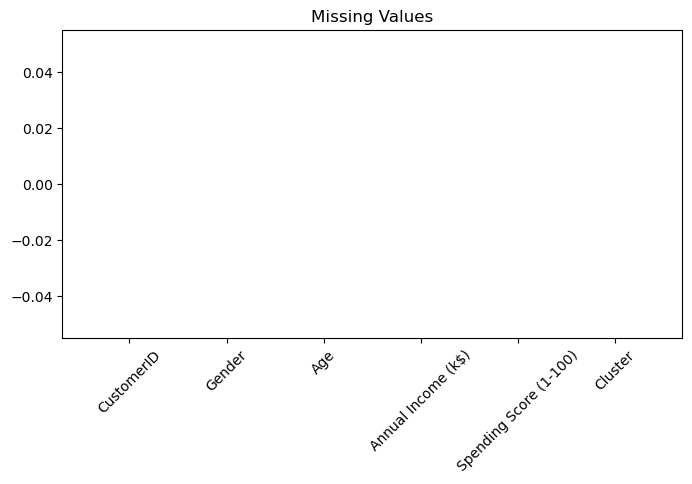

In [61]:
missing = df.isnull().sum()

plt.figure(figsize=(8,4))
plt.bar(missing.index, missing.values)
plt.title("Missing Values")
plt.xticks(rotation=45)
plt.show()

In [13]:
#Check Duplicate Rows

In [14]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [15]:
#Display Random Records

In [16]:
df.sample(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
56,57,Female,51,44,50
146,147,Male,48,77,36
77,78,Male,40,54,48
185,186,Male,30,99,97
145,146,Male,28,77,97
101,102,Female,49,62,48
7,8,Female,23,18,94
52,53,Female,31,43,54
121,122,Female,38,67,40
57,58,Male,69,44,46


In [17]:
#Age Distribution

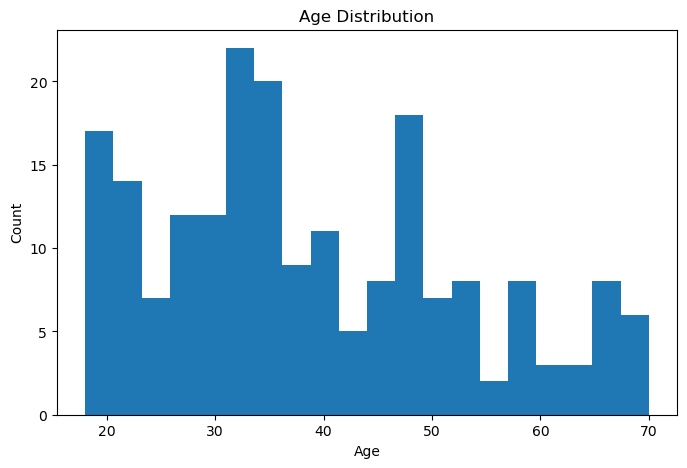

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

In [19]:
#Gender Distribution

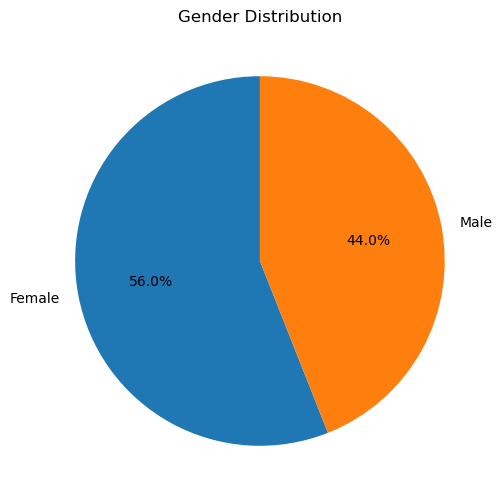

In [20]:
gender = df["Gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender.values,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

In [21]:
#Income Distribution

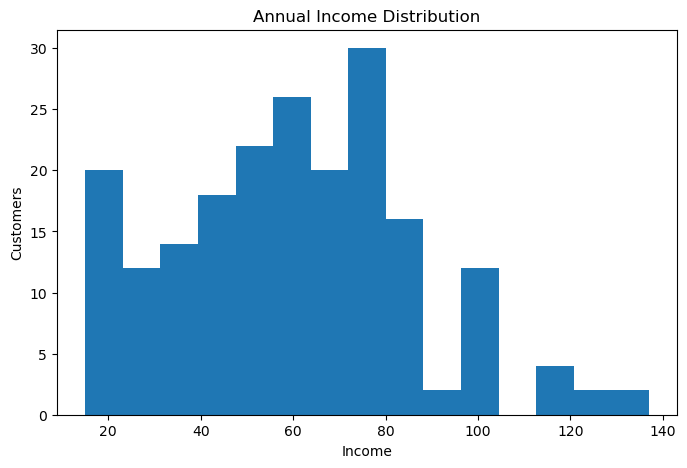

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df["Annual Income (k$)"], bins=15)

plt.title("Annual Income Distribution")

plt.xlabel("Income")

plt.ylabel("Customers")

plt.show()

In [23]:
#Spending Score Distribution

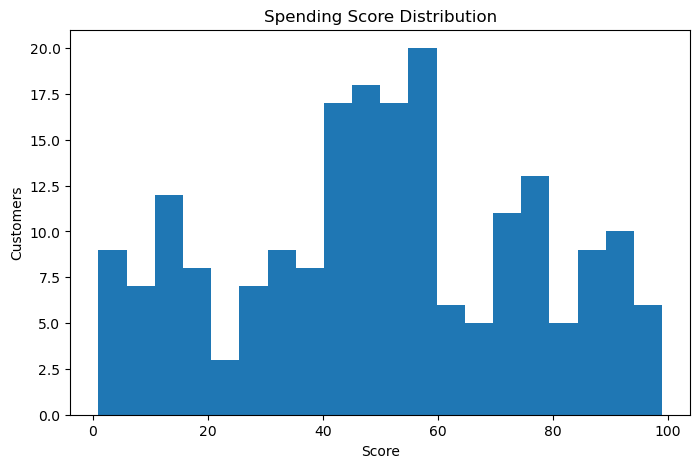

In [24]:
plt.figure(figsize=(8,5))

plt.hist(df["Spending Score (1-100)"], bins=20)

plt.title("Spending Score Distribution")

plt.xlabel("Score")

plt.ylabel("Customers")

plt.show()

In [25]:
#Age vs Spending Score

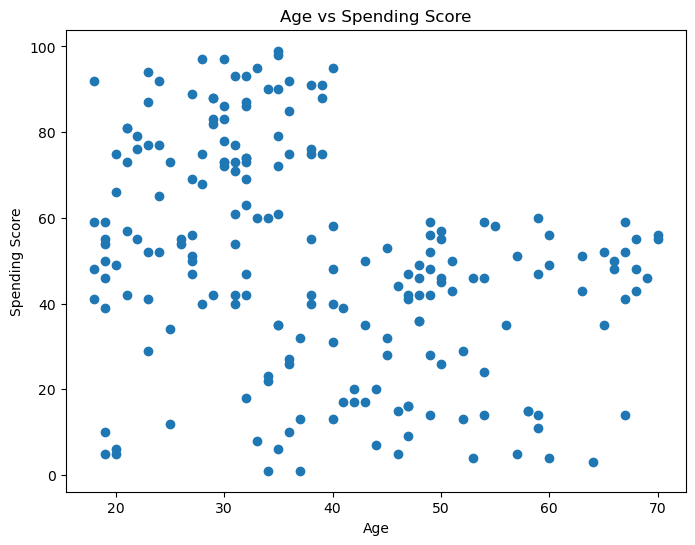

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Age"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Age")

plt.ylabel("Spending Score")

plt.title("Age vs Spending Score")

plt.show()

In [27]:
#Income vs Spending Score

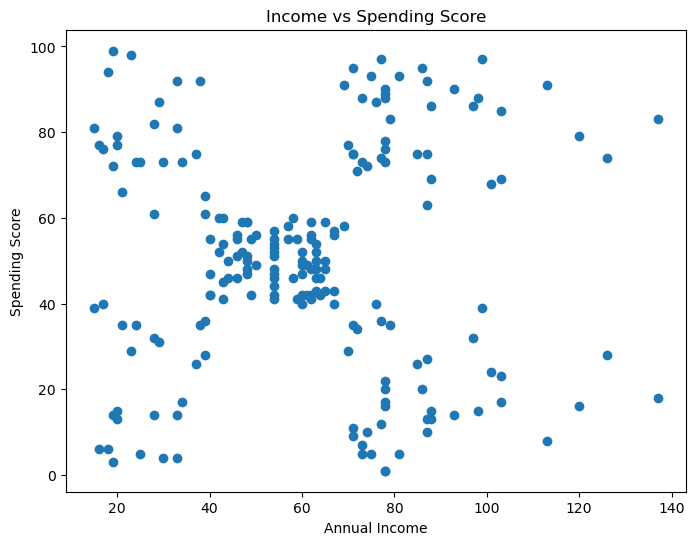

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Income vs Spending Score")

plt.show()

In [29]:
#Feature Selection

In [30]:
X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

In [31]:
#Feature Scaling

In [32]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [33]:
#Elbow Method

In [37]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

In [38]:
#Plot Elbow Curve

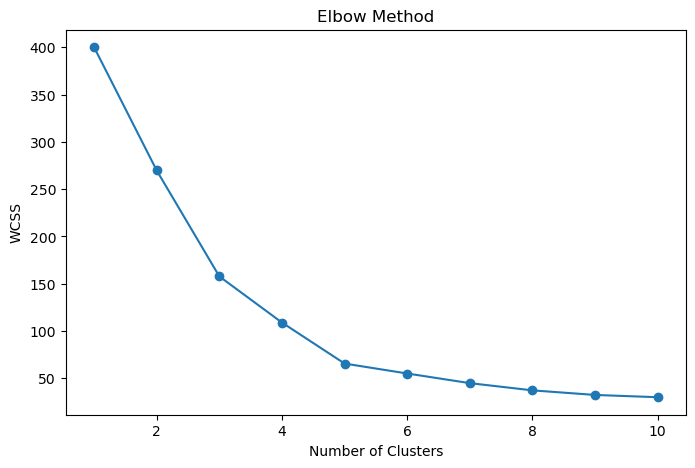

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [40]:
#Apply K-Means

In [41]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [42]:
#View Clustered Data

In [43]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [44]:
#Cluster Counts

In [45]:
df["Cluster"].value_counts().sort_index()

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

In [46]:
#Cluster Centers

In [47]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

In [48]:
#Final Cluster Visualization

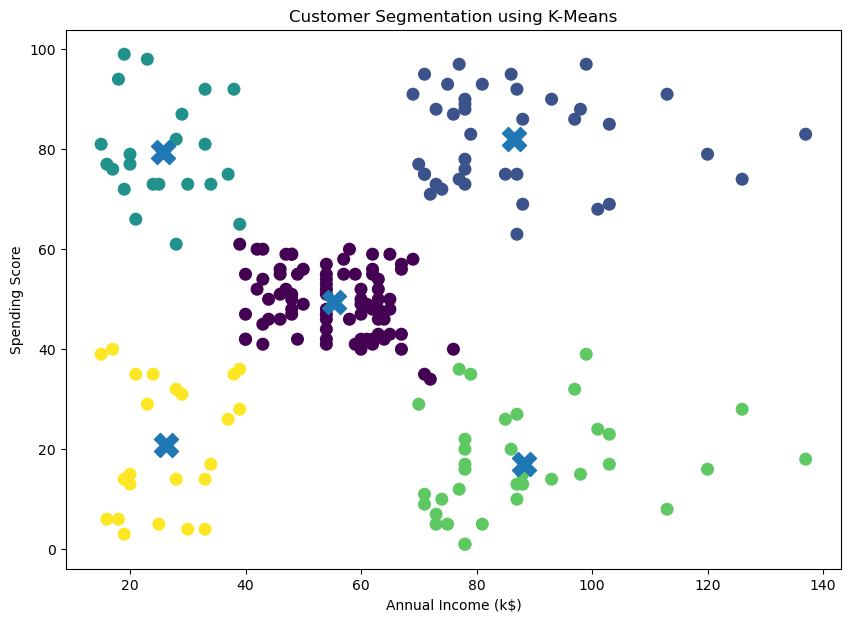

In [49]:
plt.figure(figsize=(10,7))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=70
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    s=300,
    marker="X"
)

plt.xlabel("Annual Income (k$)")

plt.ylabel("Spending Score")

plt.title("Customer Segmentation using K-Means")

plt.show()

In [50]:
#Silhouette Score

In [51]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score :", round(score,3))

Silhouette Score : 0.555


In [52]:
#Average Values of Each Cluster

In [53]:
cluster_summary = df.groupby("Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [54]:
#Customers in Each Cluster

In [55]:
df.groupby("Cluster").size()

Cluster
0    81
1    39
2    22
3    35
4    23
dtype: int64

In [56]:
#Display Each Cluster

In [58]:
for i in sorted(df["Cluster"].unique()):
    
    print("="*50)
    
    print("Cluster", i)
    
    display(df[df["Cluster"]==i].head())

Cluster 0


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
43,44,Female,31,39,61,0
46,47,Female,50,40,55,0
47,48,Female,27,40,47,0
48,49,Female,29,40,42,0
49,50,Female,31,40,42,0


Cluster 1


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
123,124,Male,39,69,91,1
125,126,Female,31,70,77,1
127,128,Male,40,71,95,1
129,130,Male,38,71,75,1
131,132,Male,39,71,75,1


Cluster 2


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
1,2,Male,21,15,81,2
3,4,Female,23,16,77,2
5,6,Female,22,17,76,2
7,8,Female,23,18,94,2
9,10,Female,30,19,72,2


Cluster 3


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
124,125,Female,23,70,29,3
128,129,Male,59,71,11,3
130,131,Male,47,71,9,3
134,135,Male,20,73,5,3
136,137,Female,44,73,7,3


Cluster 4


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
2,3,Female,20,16,6,4
4,5,Female,31,17,40,4
6,7,Female,35,18,6,4
8,9,Male,64,19,3,4


In [62]:
#Average Income by Gender

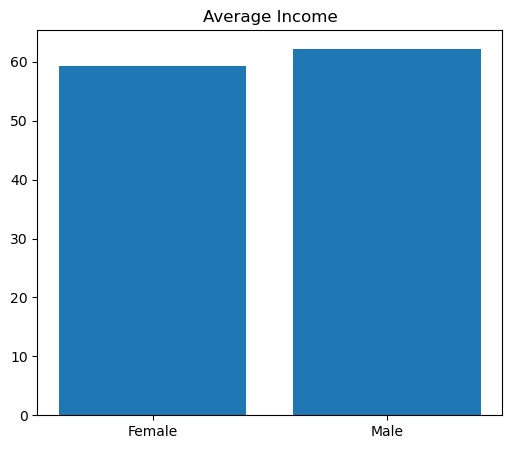

In [63]:
avg = df.groupby("Gender")["Annual Income (k$)"].mean()

plt.figure(figsize=(6,5))

plt.bar(avg.index,avg.values)

plt.title("Average Income")

plt.show()

In [64]:
#Male vs Female Spending

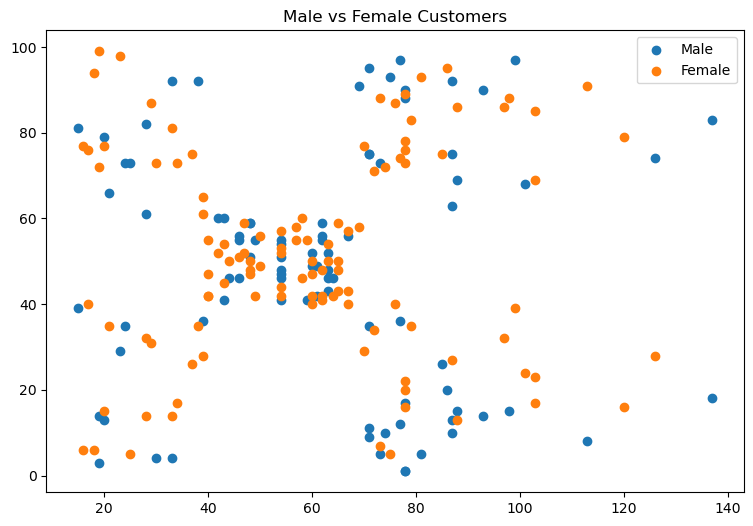

In [65]:
male = df[df["Gender"]=="Male"]
female = df[df["Gender"]=="Female"]

plt.figure(figsize=(9,6))

plt.scatter(
    male["Annual Income (k$)"],
    male["Spending Score (1-100)"],
    label="Male"
)

plt.scatter(
    female["Annual Income (k$)"],
    female["Spending Score (1-100)"],
    label="Female"
)

plt.legend()

plt.title("Male vs Female Customers")

plt.show()

In [66]:
#Average Spending by Gender

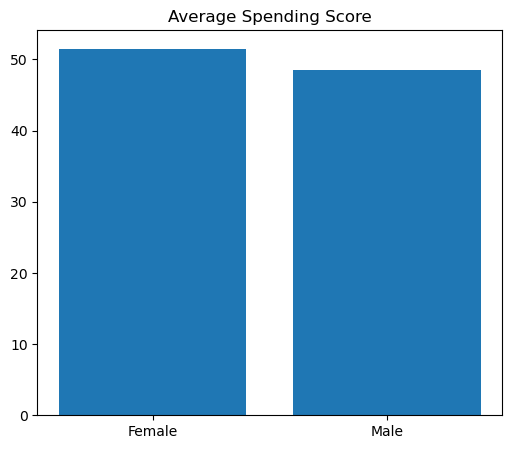

In [67]:
avg = df.groupby("Gender")["Spending Score (1-100)"].mean()

plt.figure(figsize=(6,5))

plt.bar(avg.index,avg.values)

plt.title("Average Spending Score")

plt.show()

In [68]:
#Customer Count by Gender

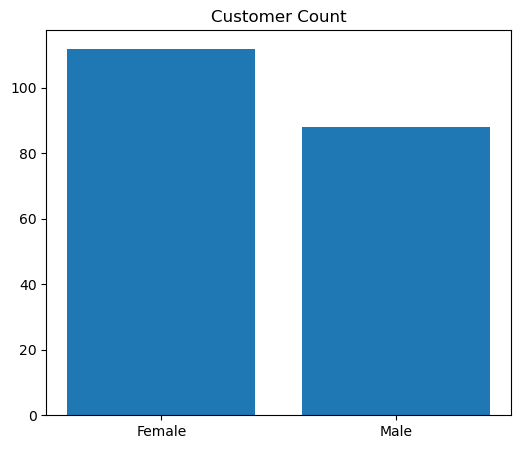

In [69]:
counts = df["Gender"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(counts.index,counts.values)

plt.title("Customer Count")

plt.show()

In [70]:
#Age Groups

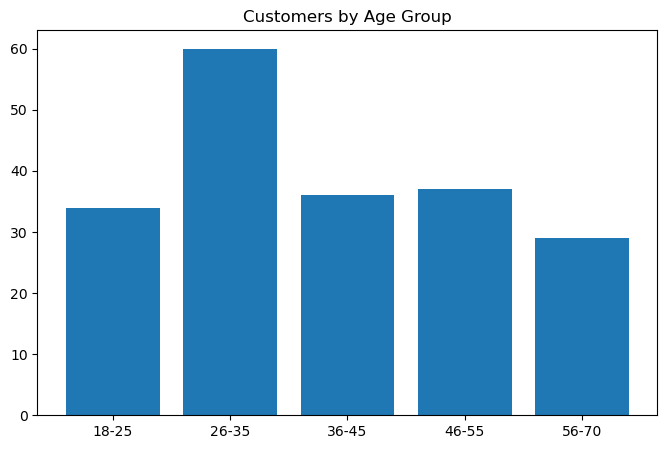

In [71]:
bins=[18,25,35,45,55,70]

labels=["18-25","26-35","36-45","46-55","56-70"]

df["Age Group"]=pd.cut(df["Age"],bins=bins,labels=labels)

age=df["Age Group"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(age.index.astype(str),age.values)

plt.title("Customers by Age Group")

plt.show()

In [72]:
#Correlation Matrix

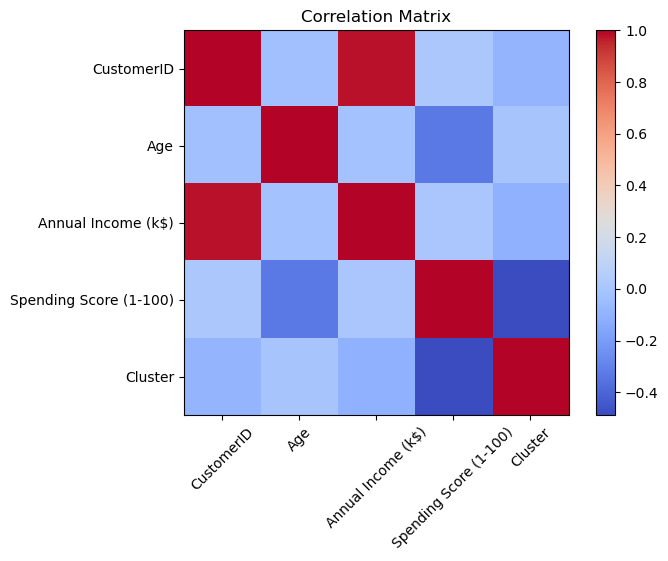

In [73]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(7,5))

plt.imshow(corr,cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)

plt.yticks(range(len(corr.columns)),corr.columns)

plt.title("Correlation Matrix")

plt.show()

In [74]:
#Cluster Distribution

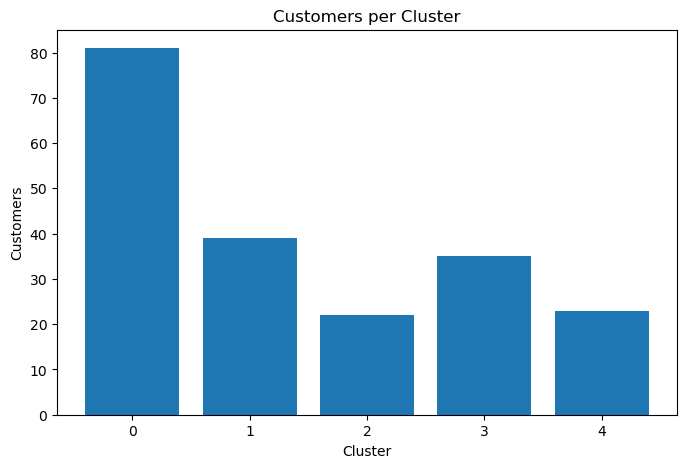

In [75]:
cluster = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(cluster.index.astype(str),cluster.values)

plt.xlabel("Cluster")

plt.ylabel("Customers")

plt.title("Customers per Cluster")

plt.show()

In [76]:
#Cluster Centers

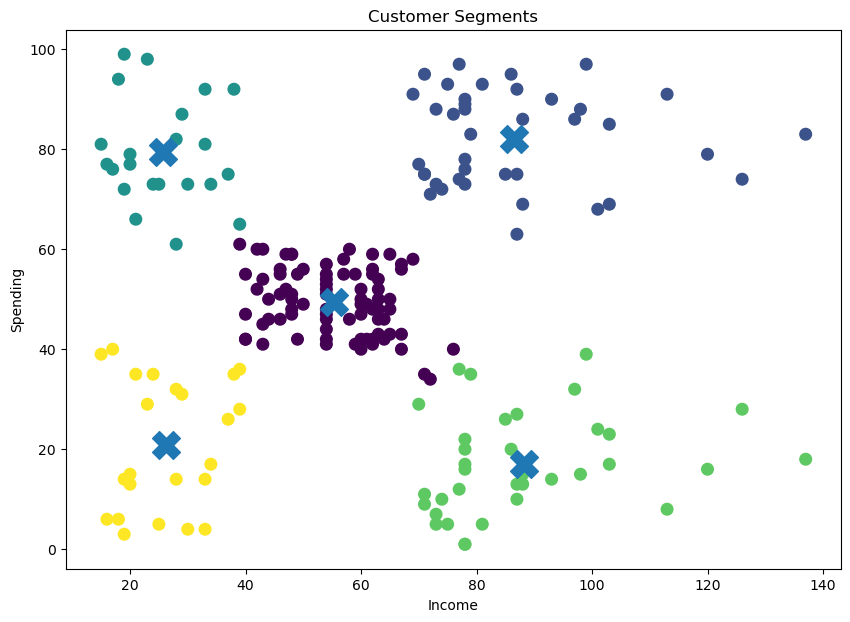

In [77]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(10,7))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=70
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    marker='X',
    s=400
)

plt.title("Customer Segments")

plt.xlabel("Income")

plt.ylabel("Spending")

plt.show()

In [78]:
#Cluster Summary

In [79]:
summary = df.groupby("Cluster").agg({

"Age":"mean",

"Annual Income (k$)":"mean",

"Spending Score (1-100)":"mean",

"CustomerID":"count"

})

summary.rename(columns={"CustomerID":"Customers"},inplace=True)

summary

,Age,Annual Income (k$),Spending Score (1-100),Customers
Cluster,,,,
0,42.716049,55.296296,49.518519,81
1,32.692308,86.538462,82.128205,39
2,25.272727,25.727273,79.363636,22
3,41.114286,88.200000,17.114286,35
4,45.217391,26.304348,20.913043,23


In [81]:
#Business Insights

# Business Insights

### Cluster 0
High Income - High Spending

Recommendation:
- VIP Membership
- Premium Offers
- Loyalty Rewards

---

### Cluster 1
Low Income - High Spending

Recommendation:
- Discounts
- Coupons
- Student Offers

---

### Cluster 2
Average Income - Average Spending

Recommendation:
- Regular Promotions
- Bundle Products

---

### Cluster 3
High Income - Low Spending

Recommendation:
- Personalized Marketing
- Premium Product Recommendations

---

### Cluster 4
Low Income - Low Spending

Recommendation:
- Budget-Friendly Campaigns
- Seasonal Discounts

In [80]:
#Conclusion

# Conclusion

The K-Means clustering algorithm successfully segmented customers into five groups based on Annual Income and Spending Score.

The Elbow Method indicated that five clusters provide a good balance between simplicity and accuracy.

These customer segments help businesses:
- Improve targeted marketing
- Increase customer satisfaction
- Optimize promotional campaigns
- Enhance customer retention
- Maximize revenue

In [83]:
import os

os.makedirs("output", exist_ok=True)

df.to_csv("output/Customer_Segmentation_Result.csv", index=False)

print("File saved successfully!")

File saved successfully!
